# Generate the panoramic image using the inverse warping technique
Implement a Python3 function named 'inverse_warping(best_transformation_matrix, left_image, right_image)' that performs inverse warping to produce the final panorama.

The function should return a warped grayscale image with a height of 200 pixels and a width of 420 pixels (i.e., twice the width of the input left and right images, each with a width of 210 pixels).

The input argument 'best_transformation_matrix' is a 3 × 3 homography matrix, represented as a Python3 list of lists. The arguments 'left_image' and 'right_image' are grayscale images.

When combining pixel values from the two images in overlapping regions, apply linear blending with 95% contribution from the left image and 5% contribution from the right image.

Note: Do not round any intermediate or final numerical results.

### Bilinear interpolation
![](assets/slide_images/Bilinear%20interpolation.png)
![](assets/slide_images/Bilinear%20interpolation%20example.png)

### The inverse warping algorithm 
You must strictly follow the presented algorithm
![](assets/slide_images/Inverse%20Warping%20in%20Image%20Stitching.png)

In [208]:
import math
import numpy as np
from PIL import Image

prefix = "assets/"
left_image = np.array(Image.open(prefix + "original_left_image.png").convert('L'))
right_image = np.array(Image.open(prefix + "original_right_image.png").convert('L'))
final_image = Image.open(prefix + "original_final_warped_image.png").convert('L')

best_transformation_matrix = np.array([[-0.014,    0.0,    1.0],
                                       [   0.0, -0.014,    0.0],
                                       [   0.0,    0.0, -0.014]])

### bilinear_interpolation



In [209]:
# def bilinear_interpolation(image, x, y):
#     h, w = image.shape
#     x1 = int(np.floor(x))
#     y1 = int(np.floor(y))
#     x2 = x1 + 1
#     y2 = y1 + 1

#     # limit the values in an array to a valid range
#     # numpy.clip(a, a_min, a_max, out=None, **kwargs)
#     x1 = np.clip(x1, 0, w - 1)
#     y1 = np.clip(y1, 0, h - 1)
#     x2 = np.clip(x2, 0, w - 1)
#     y2 = np.clip(y2, 0, h - 1)

#     a = x - x1
#     b = y - y1

#     return (
#         (1 - a) * (1 - b) * image[y1, x1]
#         + a * (1 - b) * image[y1, x2]
#         + (1 - a) * b * image[y2, x1]
#         + a * b * image[y2, x2]
#     )


# # 𝑓(1,2) = 100, 𝑓(2,2) = 120, 𝑓(1,1) = 110, and 𝑓(2,1) = 130
# # 𝑓(𝑥 = 1.3, 𝑦 = 1.7) = 109

# # The slide is p(x1, y1) in the bottom-left corner, denote standard Cartesian coordinates,
# # but numpy use standard matrix, p(x1, y1) is in the top-left corner, x is the column index and y is the row index,
# # so we need to swap y1 and y2 in the code.
# image = np.array([[110, 130], [100, 120]])
# x = 0.3
# y = 0.7
# bilinear_interpolation(image, x, y)

In [210]:
def inverse_warping(best_transformation_matrix, left_image, right_image):
    # assume right and left images have the same dimensions
    h, w = left_image.shape
    canvas_h = h
    
    # New canvas (coordinate system) twice the width
    canvas_w = w * 2
    warped_image = np.zeros((canvas_h, canvas_w), dtype=np.float64)
    
    def bilinear_interpolation(image, x, y):
        h, w = image.shape
        x1 = int(np.floor(x))
        y1 = int(np.floor(y))
        x2 = x1 + 1
        y2 = y1 + 1

        # limit the values in an array to a valid range
        # numpy.clip(a, a_min, a_max, out=None, **kwargs)
        x1 = np.clip(x1, 0, w - 1)
        y1 = np.clip(y1, 0, h - 1)
        x2 = np.clip(x2, 0, w - 1)
        y2 = np.clip(y2, 0, h - 1)

        a = x - x1
        b = y - y1

        return (
            (1 - a) * (1 - b) * image[y1, x1]
            + a * (1 - b) * image[y1, x2]
            + (1 - a) * b * image[y2, x1]
            + a * b * image[y2, x2]
        )
    
    T = np.array(best_transformation_matrix)
    
    for y in range(canvas_h):
        for x in range(canvas_w):
            p_canvas = np.array([x, y, 1.0])
            
            # Mapped coordinate = T (canvas coordinate)
            p_mapped = T @ p_canvas
            
            # Convert homogeneous to Cartesian coordinates
            w_mapped = p_mapped[-1]
            # not divided by zero
            if w_mapped == 0:
                continue
            x_mapped = p_mapped[0] / w_mapped
            y_mapped = p_mapped[1] / w_mapped
            
            in_img1 = (0 <= x < w) and (0 <= y < h)
            in_img2 = (0 <= x_mapped < w) and (0 <= y_mapped < h)

            # If source point inside Image-1 and mapped coordinate outside the Image-2:
            if in_img1 and not in_img2:
                # Take color value exclusively from Image-1
                warped_image[y, x] = left_image[y, x]
                
            # If source point inside Image-1 and mapped point inside Image-2
            elif in_img1 and in_img2:
                # Color-1: the corresponding color in Image-1
                color1 = left_image[y, x]
                # Color-2: the corresponding interpolated color in Image-2
                color2 = bilinear_interpolation(right_image, x_mapped, y_mapped)
                # Apply linear blending
                warped_image[y, x] = 0.95 * color1 + 0.05 * color2
                
            # If source point outside Image-1 and mapped point inside Image-2
            elif not in_img1 and in_img2:
                # Take color value exclusively from Image-2
                
                # NONE OF THE BELOW WAYS CAN GIVE THE EXACT SAME RESULT AS THE EXPECTED FINAL WARPED IMAGE,
                # BUT THE SECOND WAY IS THE CLOSEST ONE.
                
                # # FIRST way just round down the mapped coordinates to get the pixel value and not outside of right image
                # round_x_mapped = int(np.floor(x_mapped))
                # round_y_mapped = int(np.floor(y_mapped))
                # warped_image[y, x] = right_image[round_y_mapped, round_x_mapped]
                
                # SECOND way just use the nearest neighbor interpolation
                # round to the nearest integer to get the pixel value and not outside of right image
                round_x_mapped = int(np.round(x_mapped))
                round_y_mapped = int(np.round(y_mapped))
                if round_x_mapped >= w:
                    round_x_mapped = w - 1
                if round_y_mapped >= h:
                    round_y_mapped = h - 1
                warped_image[y, x] = right_image[round_y_mapped, round_x_mapped]
                
                # # THIRD way: use bilinear interpolation
                # warped_image[y, x] = bilinear_interpolation(right_image, x_mapped, y_mapped)
                
                
            # If source point outside left image & mapped point outside right image:
            # Use default value (0 for black) => DO NOTHING

    return warped_image

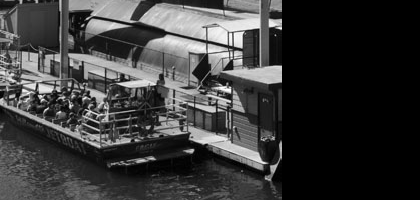

Expected final warped image:


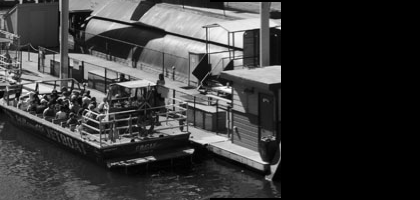

In [211]:
warped_image = inverse_warping(best_transformation_matrix, left_image, right_image)
display(Image.fromarray(np.round(warped_image).astype(np.uint8)))
print("Expected final warped image:")
final_image


In [212]:
np_final_image = np.array(final_image)
np.array_equal(np_final_image, warped_image)

False

## Comparision

Number of different pixels: 38645
Percentage: 46.01%


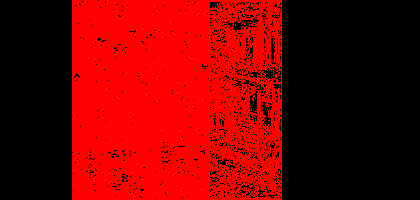

In [213]:
# count different pixels
difference = np.abs(np_final_image - warped_image)
num_different_pixels = np.sum(difference > 0)
print(f"Number of different pixels: {num_different_pixels}")
print(f"Percentage: {num_different_pixels / np_final_image.size * 100:.2f}%")

# Create a mask of different pixels
difference_mask = difference > 0
# Create an image to visualize the differences (red for different pixels, black for same pixels)
difference_image = np.zeros((difference_mask.shape[0], difference_mask.shape[1], 3), dtype=np.uint8)
difference_image[difference_mask] = [255, 0, 0]  # Red for different pixels
difference_image[~difference_mask] = [0, 0, 0]  # Black for same pixels
display(Image.fromarray(difference_image))